# Projet Getaround
🎯 Objectifs

Analyser le planning des locations de véhicules pour :

1 - Identifier les conflits :
        La location n'est pas diponible malgré la marge de temps prévue

2 - Définir et tester plusieurs seuils de temps :

3 - Choisir le seuil qui limite les conflits et les pertes pour le propriétaire du véhicule.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

### *** EDA et transformation des données *** 

In [134]:
df = pd.read_excel('src/get_around_delay_analysis.xlsx')

In [135]:
df.describe()

,rental_id,car_id,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,16346.000000,1841.000000,1841.000000
mean,549712.880338,350030.603426,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,67.000000,560823.000000,540.000000
max,576401.000000,417675.000000,71084.000000,575053.000000,720.000000


In [136]:
df.info()

valeurs_manquantes = df.isnull().sum()
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes > 0]
prc_manque = (valeurs_manquantes / len(df)) * 100
afficher_manque = pd.DataFrame({'Manquants': valeurs_manquantes, 'Pourcentage': prc_manque})

print('\nValeurs manquantes :')
print(afficher_manque)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB

Valeurs manquantes :
                                            Manquants  Pourcentage
delay_at_checkout_in_minutes                     4964    23.294228
previous_ended_re

In [137]:
# les noms des colonnes sont trops longs 
df = df.rename(columns={"checkin_type":"type",
                        "delay_at_checkout_in_minutes":"delay",
                        "previous_ended_rental_id":"previous_id",
                        "time_delta_with_previous_rental_in_minutes":"time_delta"})

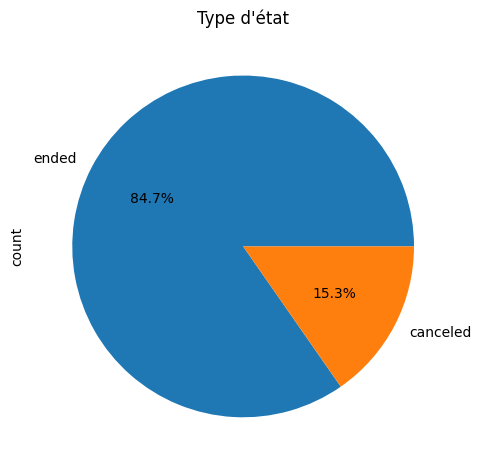

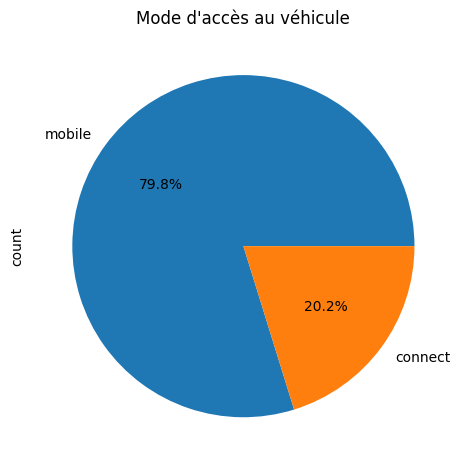

In [138]:
# focus sur les données catégorielles type et state

df['state'].value_counts().plot(kind='pie',  autopct='%1.1f%%', title="Type d'état")
plt.tight_layout()
plt.show()

# pourcentage 
df['type'].value_counts().plot(kind='pie',  autopct='%1.1f%%', title="Mode d'accès au véhicule")

plt.tight_layout()
plt.show()

Remarques :

- Les données fournies comportent pas moins de 21 310 locations
    - Parmi elles 15% soit 3260 font l'objet d'une annulation
    - Parmi elles 20% soit 4262 sont des réservations et déblocages du véhicule directement sur place


## 1 - Identifier les conflits :

In [139]:
# Le conflit est une location qui n'est pas disponible à l'heure réservée

# gestion des valeurs manquantes
# si le delay est vide alors je considère qu'il n'y a pas de retard (=0)
df["delay"] = df["delay"].fillna(0)

# si time_delta est vide alors je considère qu'il est de 12h (720 min) pour éviter tous conflits
# j'ai choisi 720 minutes car c'est le seuil métier appliqué actuellement par Getaround pour limiter les conflits
df["time_delta"] = df["time_delta"].fillna(720)

# quels sont les conflits ?
df["conflits"] = df["delay"] > df["time_delta"]


In [140]:
print('La marge actuelle de getaround réduit déjà beaucoup les conflits.')

retard_pourcentage = round((df.loc[(df["delay"]>0),:].shape[0])/len(df)*100,2)
print(f'\n\tle pourcentage actuel de retard est de {retard_pourcentage}%')

conflits_pourcentage_global = round((df.loc[(df["conflits"]==True),:].shape[0])/len(df)*100,2)
conflits_pourcentage = round(retard_pourcentage/(df.loc[(df["conflits"]==True),:].shape[0])*100,2)


print(f'\n\tle pourcentage actuel de conflit est de {conflits_pourcentage_global}% par rapport à toutes les locations.')
print(f'\n\t\t-> mais cela ne représente que {conflits_pourcentage}%  des retards')



La marge actuelle de getaround réduit déjà beaucoup les conflits.

	le pourcentage actuel de retard est de 44.13%

	le pourcentage actuel de conflit est de 3.43% par rapport à toutes les locations.

		-> mais cela ne représente que 6.04%  des retards


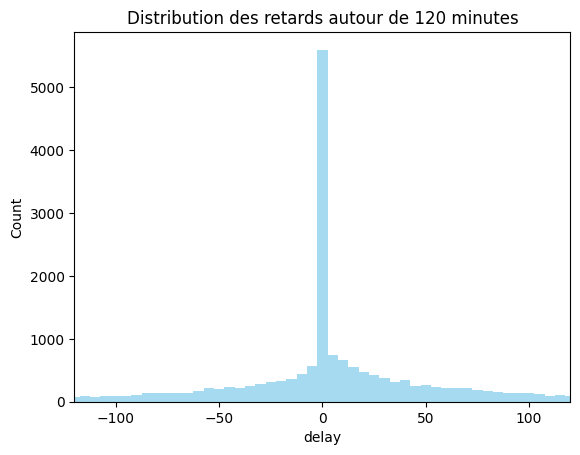

On voit massivement des retours à l'heure prévue, avec une asynmétrie vers les retards


In [141]:

sns.histplot(df["delay"], binwidth=5, color='skyblue')

plt.xlim(-120, 120) 
plt.title("Distribution des retards autour de 120 minutes")
plt.show()
print("On voit massivement des retours à l'heure prévue, avec une asynmétrie vers les retards")

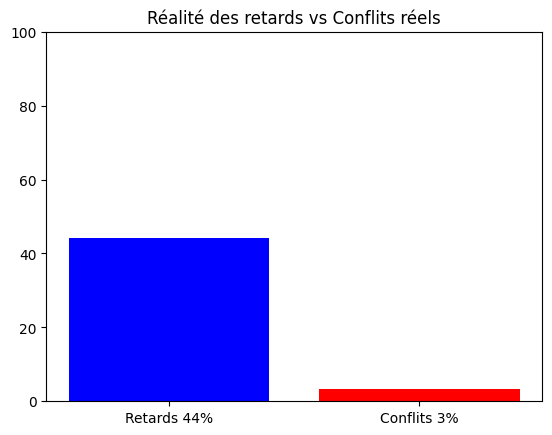

In [142]:
# forcer l'échelle à 100%
plt.ylim(0, 100)
plt.bar(['Retards 44%', 'Conflits 3%'], [retard_pourcentage, conflits_pourcentage_global], color=['blue', 'red'])
plt.title("Réalité des retards vs Conflits réels")
plt.show()

## 2 - Définir et tester plusieurs seuils de temps :

In [143]:
seuils = [0, 15, 30, 45, 60, 120 , 240 , 300 ]
projection_conflits = []


for seuil in seuils:
    # pour chaque seuil on prend tous les retards qui génèrent un conflit ou qui sont supérieur au seuil
    impact = (df['delay'] > df['time_delta']) & (df['delay'] > seuil)
    nb_incidents = impact.sum()
    pct_impact = impact.mean() * 100
    
    projection_conflits.append({'seuil_min': seuil, 'incidents_evites': nb_incidents, 'pourcentage': pct_impact})

# 3. On crée un DataFrame pour un résultat propre
df_seuils = pd.DataFrame(projection_conflits)
print(df_seuils)



   seuil_min  incidents_evites  pourcentage
0          0               731     3.430314
1         15               702     3.294228
2         30               686     3.219146
3         45               661     3.101830
4         60               637     2.989207
5        120               581     2.726420
6        240               534     2.505866
7        300               519     2.435476


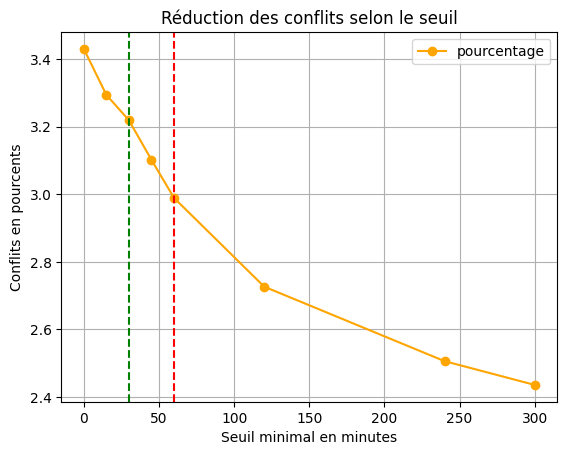

In [144]:
df_seuils.plot(x='seuil_min', y='pourcentage', marker='o', color='orange', grid=True)

# ajout de lignes verticales pour la zone 30-60 minutes
plt.axvline(x=30, color='green', linestyle='--')
plt.axvline(x=60, color='red', linestyle='--')

plt.title("Réduction des conflits selon le seuil")
plt.xlabel("Seuil minimal en minutes")
plt.ylabel("Conflits en pourcents")
plt.show()

## 3 - Choisir le seuil qui limite les conflits et les pertes pour le propriétaire du véhicule.

In [ ]:
seuil_getaround_conflit = df.loc[(df['conflits']==True),['conflits']].count()


731


/tmp/ipykernel_904/557197710.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(seuil_getaround_conflit[0])


# Conclusion:

Un seuil de 45 minutes supplémentaires serait un bon compromis entre la diminution du nombre de conflits et l'augmentation du temps d'immobilisation du véhicule.